# Regression

## 1. Problem formulation
In this notebook, we'll focus on *regression*, using an example based on a real study in which data for a bicycle sharing scheme was collected and used to predict the number of rentals based on seasonality and weather conditions. We'll use a simplified version of the dataset from that study.


## 2 Data collection and labelling

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# load the training dataset
df = pd.read_csv('daily-bike-share.csv')
# df = pd.read_csv('/content/sample_data/daily-bike-share.csv') # upload CSV file in Colab,

print(df.head())

   day  mnth  year  season  holiday  weekday  workingday  weathersit  \
0    1     1  2011       1        0        6           0           2   
1    2     1  2011       1        0        0           0           2   
2    3     1  2011       1        0        1           1           1   
3    4     1  2011       1        0        2           1           1   
4    5     1  2011       1        0        3           1           1   

       temp     atemp       hum  windspeed  rentals  
0  0.344167  0.363625  0.805833   0.160446      331  
1  0.363478  0.353739  0.696087   0.248539      131  
2  0.196364  0.189405  0.437273   0.248309      120  
3  0.200000  0.212122  0.590435   0.160296      108  
4  0.226957  0.229270  0.436957   0.186900       82  


The data consists of the following columns:

- **instant**: A unique row identifier
- **day**: The date on which the data was observed - in this case, the data was collected daily; so there's one row per date.
- **mnth**: The calendar month in which the observation was made (1:January ... 12:December)
- **yr**: The year of the study in which the observation was made (the study took place over two years - year 0 represents 2011, and year 1 represents 2012)
- **season**: A numerically encoded value indicating the season (1:spring, 2:summer, 3:fall, 4:winter)
- **holiday**: A binary value indicating whether or not the observation was made on a public holiday)
- **weekday**: The day of the week on which the observation was made (0:Sunday ... 6:Saturday)
- **workingday**: A binary value indicating whether or not the day is a working day (not a weekend or holiday)
- **weathersit**: A categorical value indicating the weather situation (1:clear, 2:mist/cloud, 3:light rain/snow, 4:heavy rain/hail/snow/fog)
- **temp**: The temperature in celsius (**normalized**)
- **atemp**: The apparent ("feels-like") temperature in celsius (**normalized**)
- **hum**: The humidity level (**normalized**)
- **windspeed**: The windspeed (**normalized**)
- **rentals**: The number of bicycle rentals recorded.

In this dataset, **rentals** represents the label (the *y* value) our model must be trained to predict. The other columns are potential features (*x* values).

As mentioned previously, you can perform some *feature engineering* to combine or derive new features. For example, let's add a new column named **day** to the dataframe by extracting the day component from the existing **dteday** column. The new column represents the day of the month from 1 to 31.

OK, let's start our analysis of the data by examining a few key descriptive statistics. We can use the dataframe's **describe** method to generate these for the numeric features as well as the **rentals** label column.

### Repairing Data Types
Beside missing data and missing missing data, there's another thing that can make you loos your cool, while working with data: wrong data types. When we watch the "dypes"-Attribute of one of the frames, we see that some variables have an impractical data type. For example should "workingday" be a binary variable that indicates if the day is a workingday (1) or not (0). But when the datatype is set to an integer, this can cause trouble. For example regression techniques would treat the variable as an integer instead of a binary variable.

In [8]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   day         731 non-null    int64  
 1   mnth        731 non-null    int64  
 2   year        731 non-null    int64  
 3   season      731 non-null    int64  
 4   holiday     731 non-null    int64  
 5   weekday     731 non-null    int64  
 6   workingday  731 non-null    int64  
 7   weathersit  731 non-null    int64  
 8   temp        731 non-null    float64
 9   atemp       731 non-null    float64
 10  hum         731 non-null    float64
 11  windspeed   731 non-null    float64
 12  rentals     731 non-null    int64  
dtypes: float64(4), int64(9)
memory usage: 74.4 KB
None


Because we have to repair the datatypes for both frames and we also want to learn something about programming as a side effect, we write a function for this task. It takes the dataframe, converts the variable "date" into datetime-format, all the categorial data into 'category' respectively 'bool'-format, gives meaningful names to all categories and returns a repaired frame.

In [9]:
# Fixing the datatypes 
df.loc[:,'season':'mnth'] = df.loc[:,'season':'mnth'].astype('category')
df[['holiday','workingday']] = df[['holiday','workingday']].astype('bool')
df[['weekday','weathersit']] = df[['weekday','weathersit']].astype('category')

# Get Meaningful Names for the categorial Variables
mapping_season = {1:"1_Winter", 2:"2_Spring", 3:"3_Summer", 4:"4_Fall" }
mapping_weekdays = {0:"Sunday", 1:"Monday", 2:"Tuesday", 3:"Wednesday", 
                    4:"Thursday", 5:"Friday", 6:"Saturday"}
mapping_weather = {1:"good", 2:"medium", 3:"poor", 4:"very_poor" }

df["season"] = df.season.map(mapping_season)
df["weekday"] = df.weekday.map(mapping_weekdays)
df["weathersit"] = df.weathersit.map(mapping_weather)

In [10]:
# now lets see our data types after the above change.
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   day         731 non-null    int64   
 1   mnth        731 non-null    int64   
 2   year        731 non-null    int64   
 3   season      731 non-null    object  
 4   holiday     731 non-null    bool    
 5   weekday     731 non-null    category
 6   workingday  731 non-null    bool    
 7   weathersit  731 non-null    category
 8   temp        731 non-null    float64 
 9   atemp       731 non-null    float64 
 10  hum         731 non-null    float64 
 11  windspeed   731 non-null    float64 
 12  rentals     731 non-null    int64   
dtypes: bool(2), category(2), float64(4), int64(4), object(1)
memory usage: 54.9+ KB
None


In [11]:
print(df.head(10))

   day  mnth  year    season  holiday    weekday  workingday weathersit  \
0    1     1  2011  1_Winter    False   Saturday       False     medium   
1    2     1  2011  1_Winter    False     Sunday       False     medium   
2    3     1  2011  1_Winter    False     Monday        True       good   
3    4     1  2011  1_Winter    False    Tuesday        True       good   
4    5     1  2011  1_Winter    False  Wednesday        True       good   
5    6     1  2011  1_Winter    False   Thursday        True       good   
6    7     1  2011  1_Winter    False     Friday        True     medium   
7    8     1  2011  1_Winter    False   Saturday       False     medium   
8    9     1  2011  1_Winter    False     Sunday       False       good   
9   10     1  2011  1_Winter    False     Monday        True       good   

       temp     atemp       hum  windspeed  rentals  
0  0.344167  0.363625  0.805833   0.160446      331  
1  0.363478  0.353739  0.696087   0.248539      131  
2  0.196364 

In [12]:
# Lets see the percentage of values in column weathersit
df['weathersit'].value_counts(normalize=True)

weathersit
good      0.633379
medium    0.337893
poor      0.028728
Name: proportion, dtype: float64

## 4 EDA

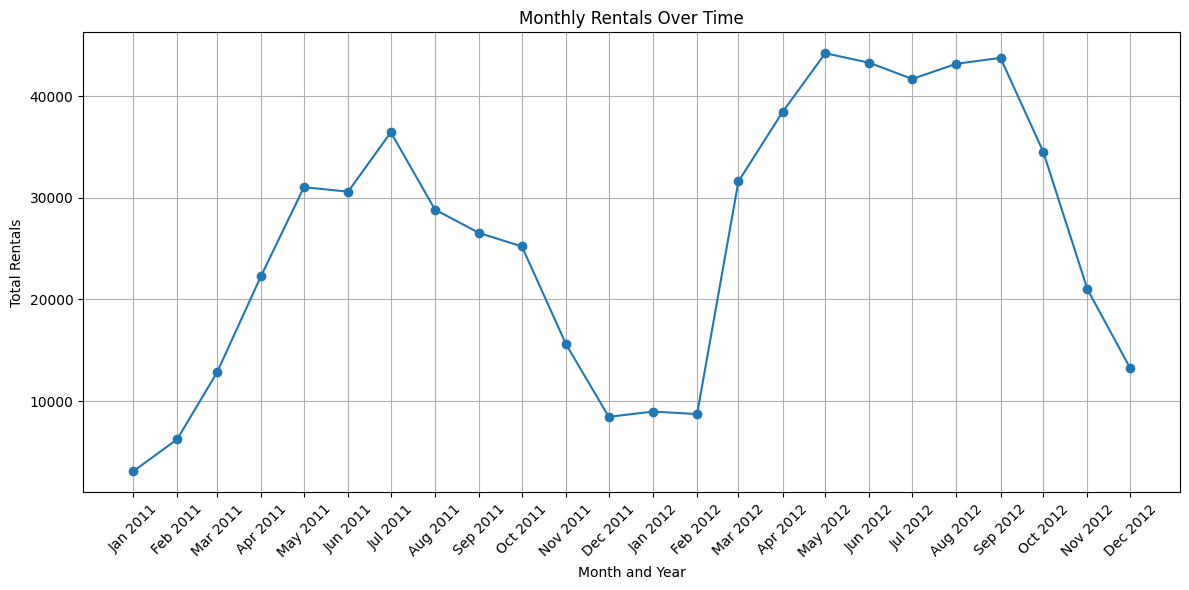

In [13]:
# Step 1: Create a datetime column using the correct column names
df['date'] = pd.to_datetime(df[['year', 'mnth']].rename(columns={'mnth': 'month'}).assign(day=1))

# Step 2: Group by the new 'date' and sum rentals
monthly_rentals = df.groupby('date')['rentals'].sum().reset_index()

# Step 3: Plot
plt.figure(figsize=(12, 6))
plt.plot(monthly_rentals['date'], monthly_rentals['rentals'], marker='o', linestyle='-')
plt.title('Monthly Rentals Over Time')
plt.xlabel('Month and Year')
plt.ylabel('Total Rentals')
plt.grid(True)
# Format x-axis ticks as "Jan 2011", "Feb 2011", ...
plt.xticks(ticks=monthly_rentals['date'], labels=monthly_rentals['date'].dt.strftime('%b %Y'), rotation=45)

plt.tight_layout()
plt.show()


### observation:
Seems like people don't wanted bikes in February.

In [14]:
numeric_features = ['temp', 'atemp', 'hum', 'windspeed']
df[numeric_features + ['rentals']].describe()

,temp,atemp,hum,windspeed,rentals
count,731.000000,731.000000,731.000000,731.000000,731.000000
mean,0.495385,0.474354,0.627894,0.190486,848.176471
std,0.183051,0.162961,0.142429,0.077498,686.622488
min,0.059130,0.079070,0.000000,0.022392,2.000000
25%,0.337083,0.337842,0.520000,0.134950,315.500000
50%,0.498333,0.486733,0.626667,0.180975,713.000000
75%,0.655417,0.608602,0.730209,0.233214,1096.000000
max,0.861667,0.840896,0.972500,0.507463,3410.000000


The statistics reveal some information about the distribution of the data in each of the numeric fields, including the number of observations (there are 731 records), the mean, standard deviation, minimum and maximum values, and the quartile values (the threshold values for 25%, 50% - which is also the median, and 75% of the data). From this, we can see that the mean number of daily rentals is around 848; but there's a comparatively large standard deviation, indicating a lot of variance in the number of rentals per day.

We might get a clearer idea of the distribution of rentals values by visualizing the data. Common plot types for visualizing numeric data distributions are *histograms* and *box plots*, so let's use Python's **matplotlib** library to create one of each of these for the **rentals** column.

C:\Users\hi\AppData\Local\Temp\ipykernel_4560\498138540.py:30: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


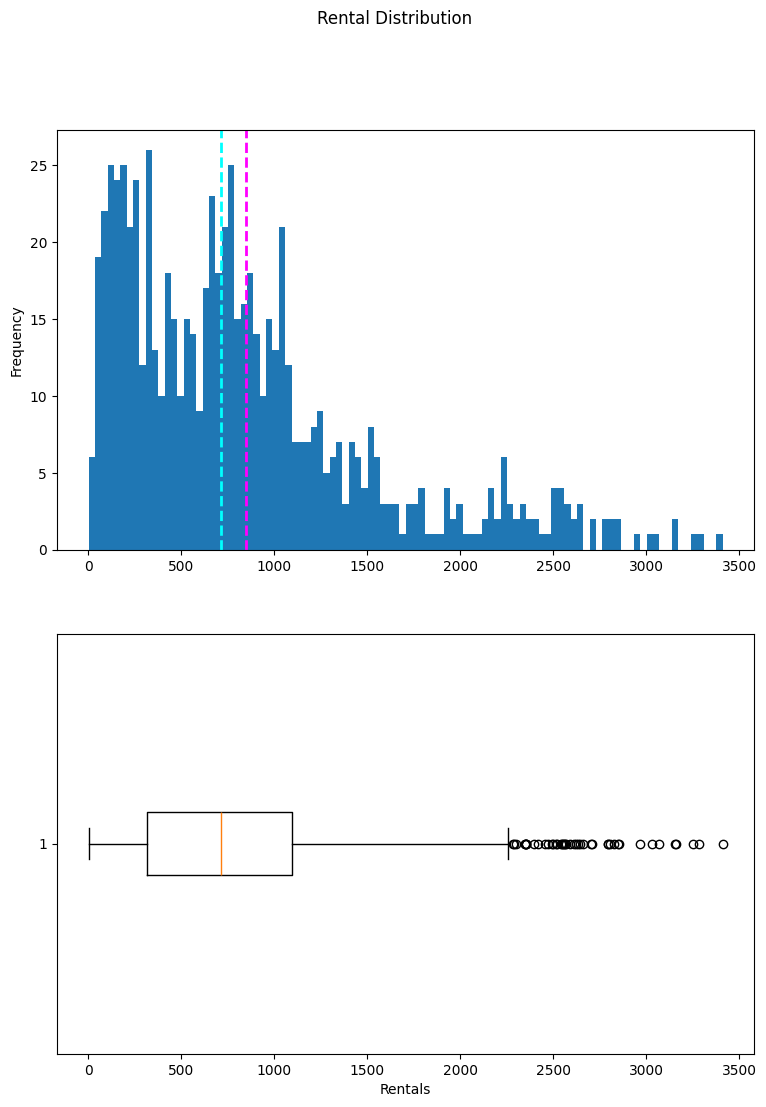

In [15]:

# This ensures plots are displayed inline in the Jupyter notebook
%matplotlib inline

# Get the label column
label = df['rentals']


# Create a figure for 2 subplots (2 rows, 1 column)
fig, ax = plt.subplots(2, 1, figsize = (9,12))

# Plot the histogram
ax[0].hist(label, bins=100)
ax[0].set_ylabel('Frequency')

# Add lines for the mean, median, and mode
ax[0].axvline(label.mean(), color='magenta', linestyle='dashed', linewidth=2)
ax[0].axvline(label.median(), color='cyan', linestyle='dashed', linewidth=2)

# Plot the boxplot
ax[1].boxplot(label, vert=False)
ax[1].set_xlabel('Rentals')

# Add a title to the Figure
fig.suptitle('Rental Distribution')

# Show the figure
fig.show()


In [ ]:
# TODO print the outliers

The plots show that the number of daily rentals ranges from 0 to just over 3,400. However, the mean (and median) number of daily rentals is closer to the low end of that range, with most of the data between 0 and around 2,200 rentals. The few values above this are shown in the box plot as small circles, indicating that they are *outliers* - in other words, unusually high or low values beyond the typical range of most of the data.

We can do the same kind of visual exploration of the numeric features. Let's create a histogram for each of these.

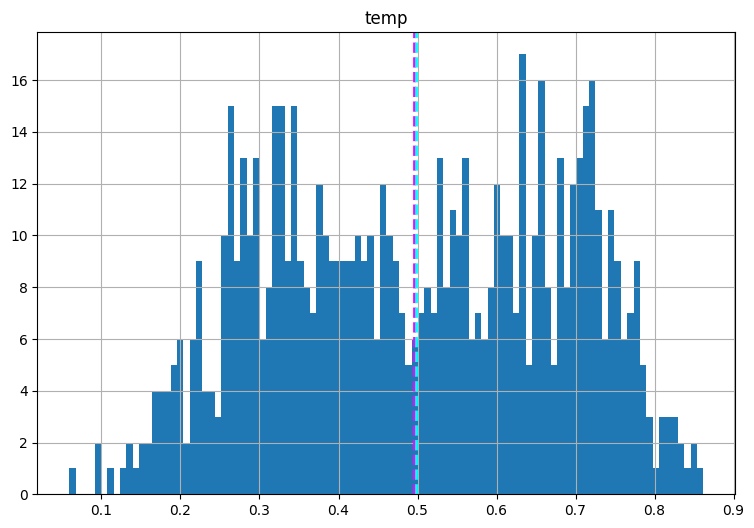

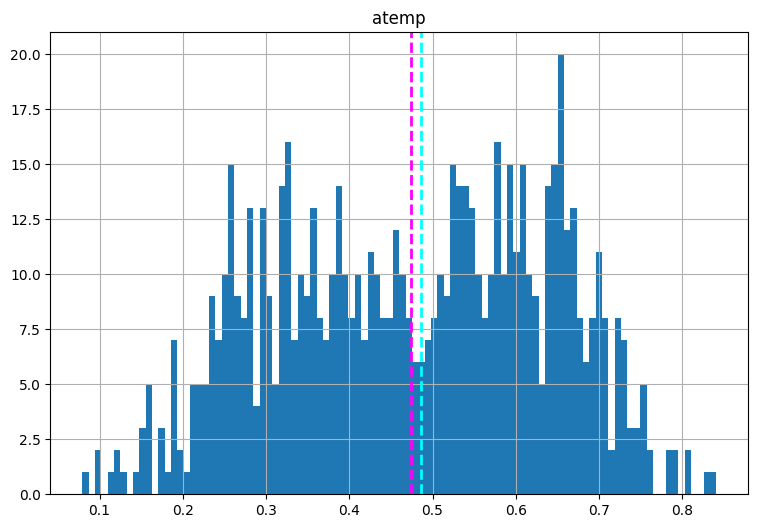

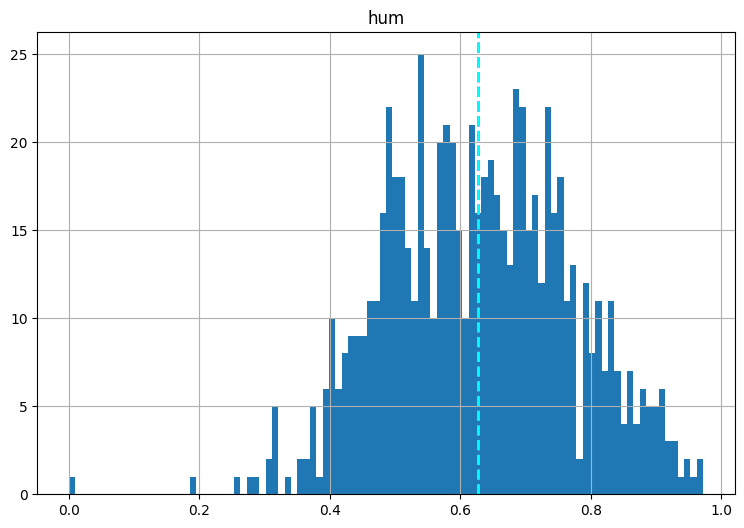

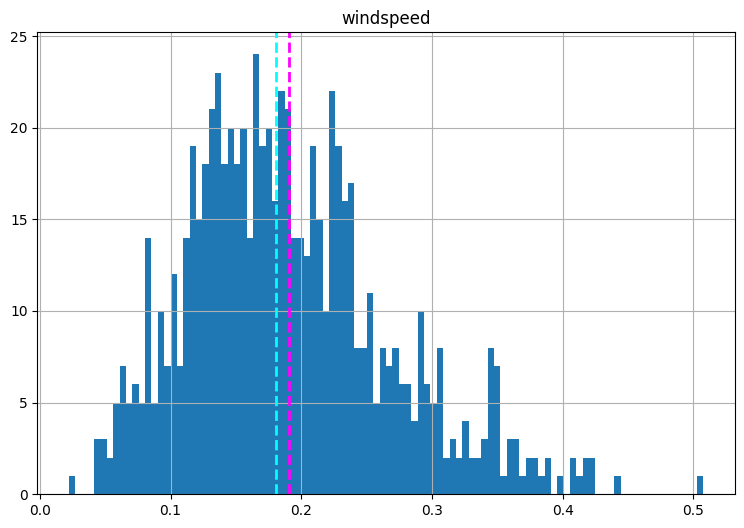

In [16]:
# Plot a histogram for each numeric feature
for col in numeric_features:
    fig = plt.figure(figsize=(9, 6))
    ax = fig.gca()
    feature = df[col]
    feature.hist(bins=100, ax = ax)
    ax.axvline(feature.mean(), color='magenta', linestyle='dashed', linewidth=2)
    ax.axvline(feature.median(), color='cyan', linestyle='dashed', linewidth=2)
    ax.set_title(col)
plt.show()

The numeric features seem to be more *normally* distributed, with the mean and median nearer the middle of the range of values, coinciding with where the most commonly occurring values are.

> **Note**: The distributions are not truly *normal* in the statistical sense, which would result in a smooth, symmetric "bell-curve" histogram with the mean and mode (the most common value) in the center; but they do generally indicate that most of the observations have a value somewhere near the middle.

We've explored the distribution of the numeric values in the dataset, but what about the categorical features? These aren't continuous numbers on a scale, so we can't use histograms; but we can plot a bar chart showing the count of each discrete value for each category.

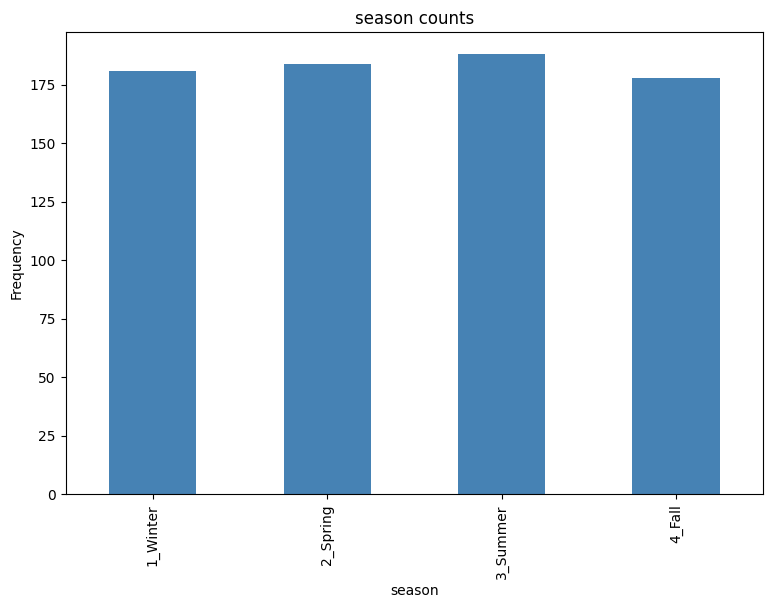

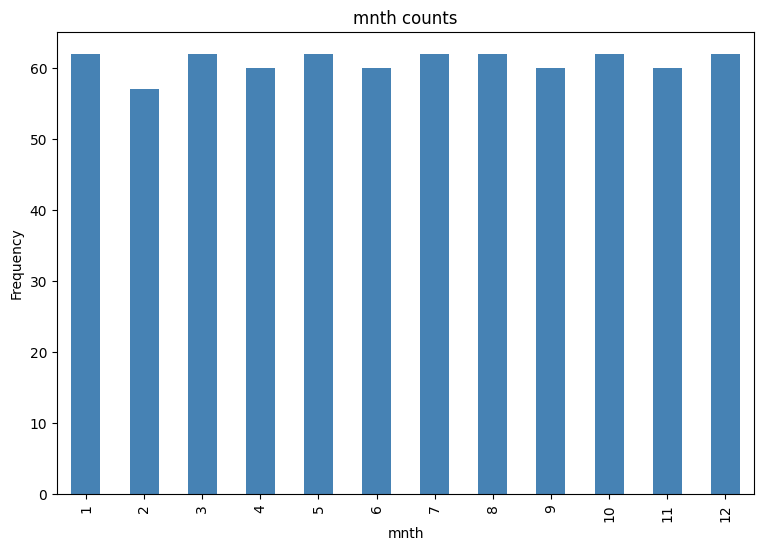

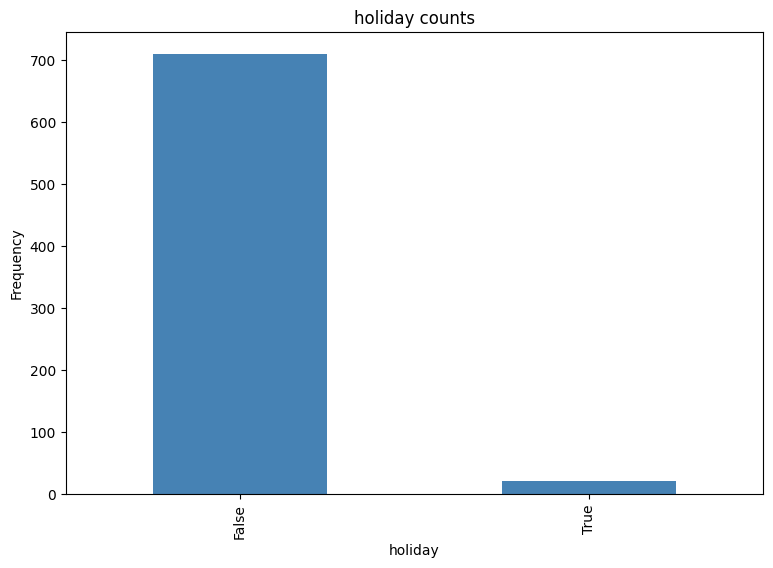

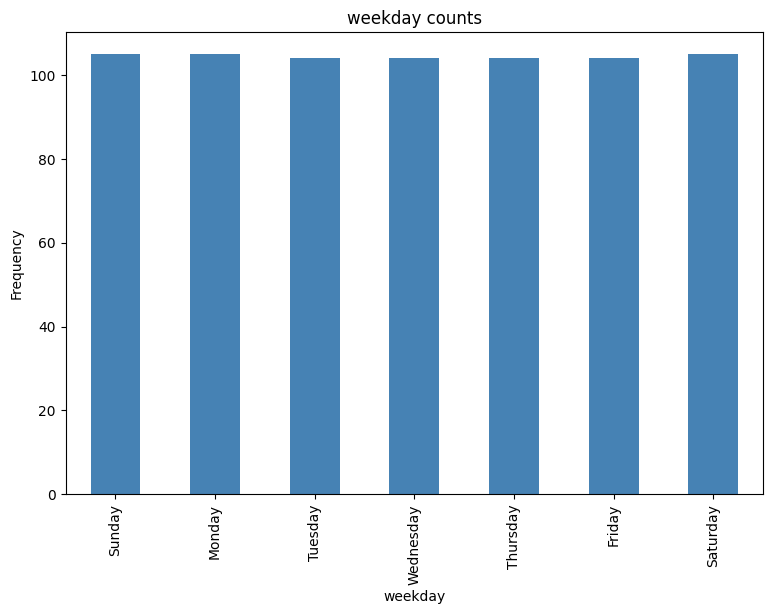

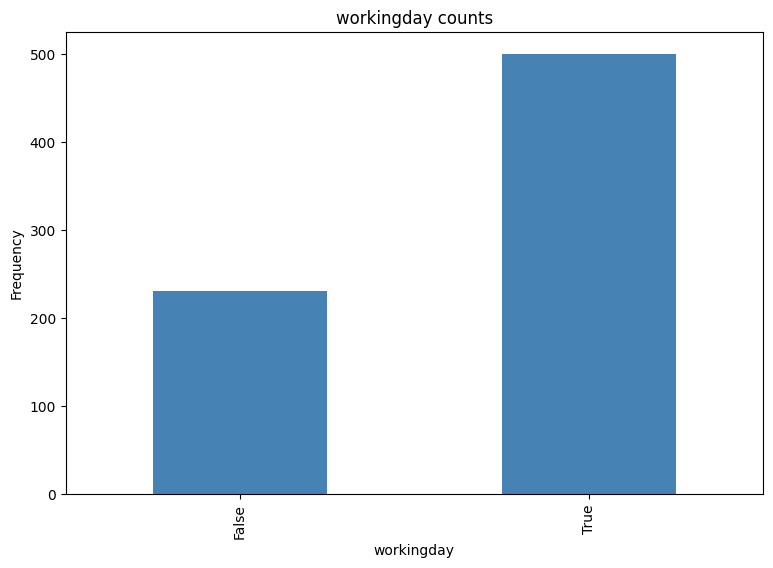

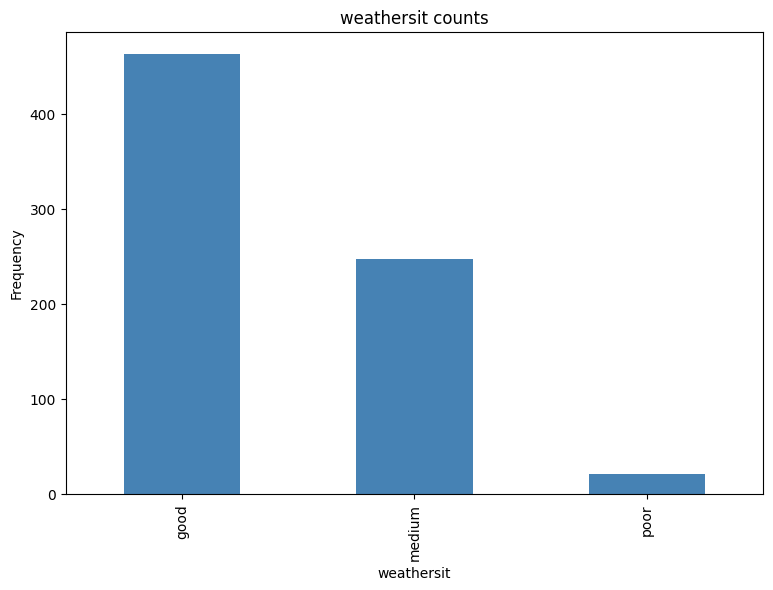

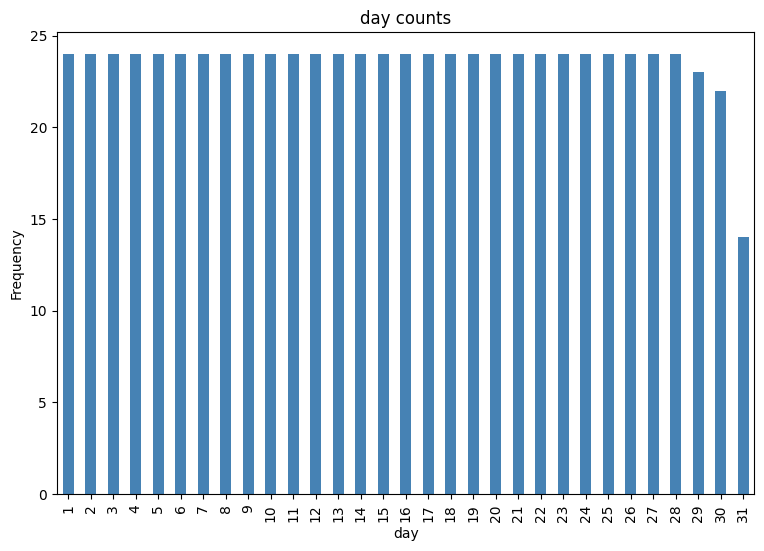

In [17]:
import numpy as np

# plot a bar plot for each categorical feature count
categorical_features = ['season','mnth','holiday','weekday','workingday','weathersit', 'day']

for col in categorical_features:
    counts = df[col].value_counts().sort_index()
    fig = plt.figure(figsize=(9, 6))
    ax = fig.gca()
    counts.plot.bar(ax = ax, color='steelblue')
    ax.set_title(col + ' counts')
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")
plt.show()


Many of the categorical features show a more or less *uniform* distribution (meaning there's roughly the same number of rows for each category). Exceptions to this include:

- **holiday**: There are many fewer days that are holidays than days that aren't.
- **workingday**: There are more working days than non-working days.
- **weathersit**: Most days are category *1* (clear), with category *2* (mist and cloud) the next most common. There are comparatively few category *3* (light rain or snow) days, and no category *4* (heavy rain, hail, or fog) days at all.

Now that we know something about the distribution of the data in our columns, we can start to look for relationships between the features and the **rentals** label we want to be able to predict.

For the numeric features, we can create scatter plots that show the intersection of feature and label values. We can also calculate the *correlation* statistic to quantify the apparent relationship..

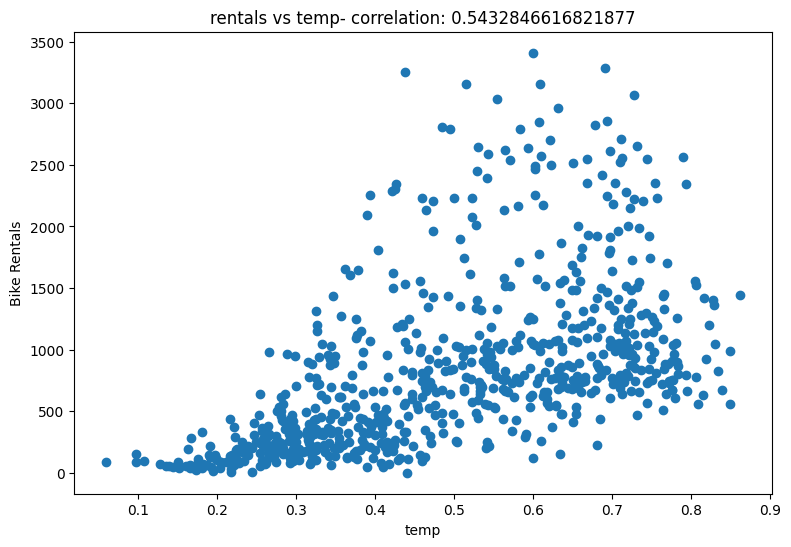

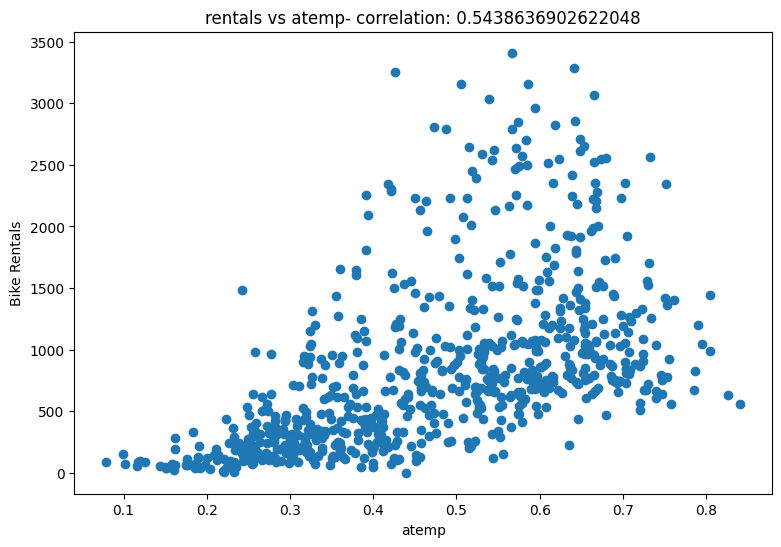

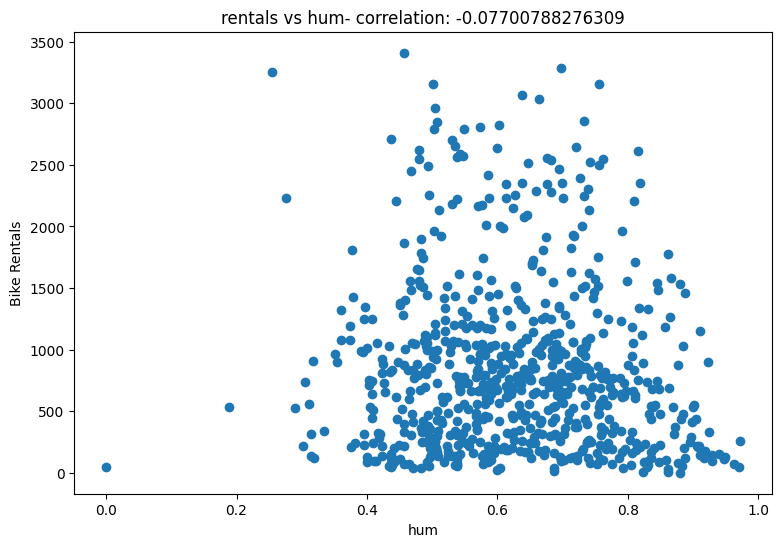

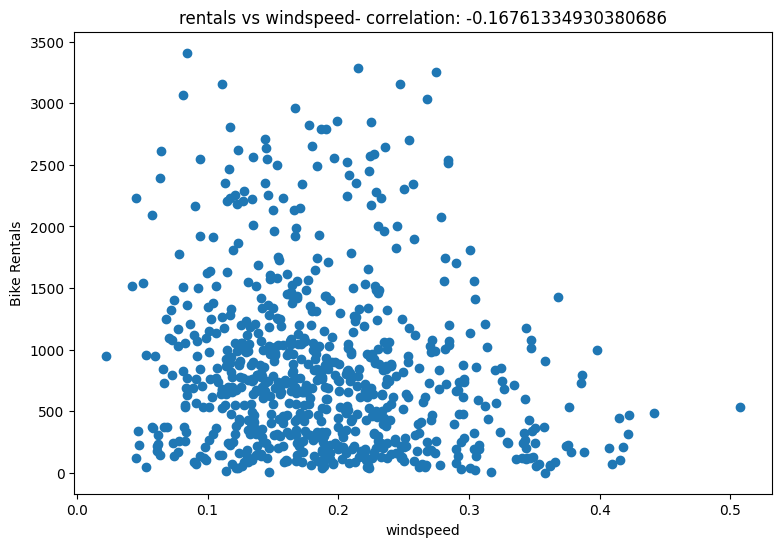

In [18]:
for col in numeric_features:
    fig = plt.figure(figsize=(9, 6))
    ax = fig.gca()
    feature = df[col]
    label = df['rentals']
    correlation = feature.corr(label)
    plt.scatter(x=feature, y=label)
    plt.xlabel(col)
    plt.ylabel('Bike Rentals')
    ax.set_title('rentals vs ' + col + '- correlation: ' + str(correlation))
plt.show()


The results aren't conclusive, but if you look closely at the scatter plots for **temp** and **atemp**, you can see a vague diagonal trend showing that higher rental counts tend to coincide with higher temperatures; and a correlation value of just over 0.5 for both of these features supports this observation. Conversely, the plots for **hum** and **windspeed** show a slightly negative correlation, indicating that there are fewer rentals on days with high humidity or windspeed.

Now let's compare the categorical features to the label. We'll do this by creating box plots that show the distribution of rental counts for each category.

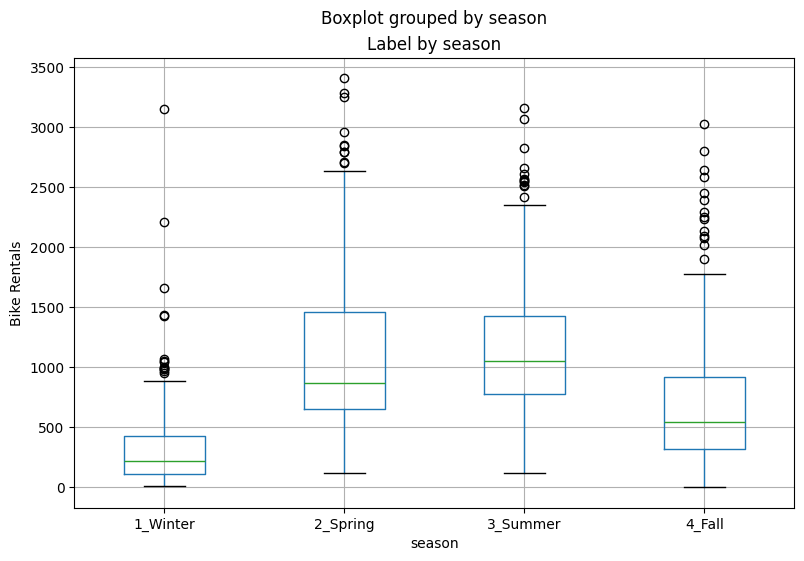

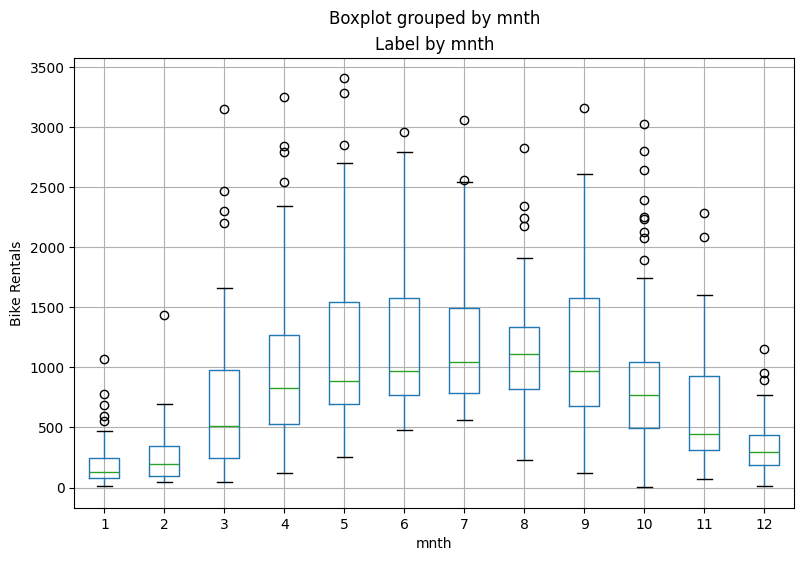

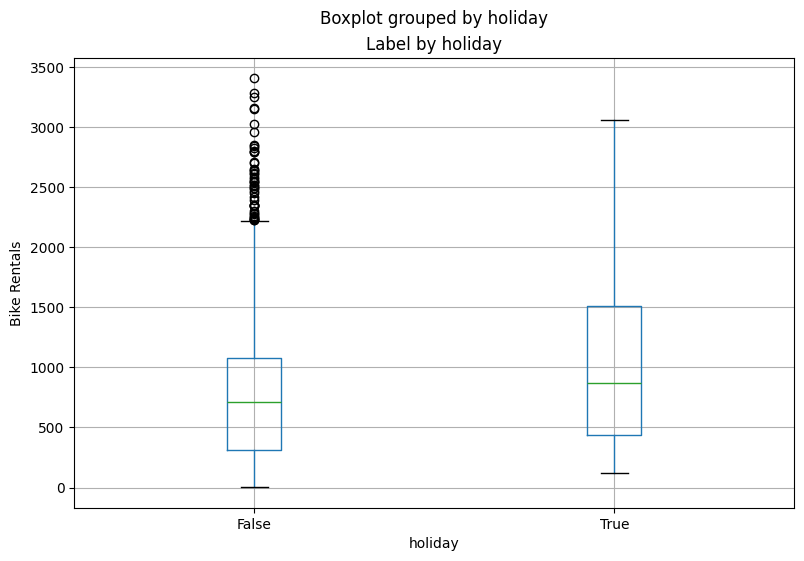

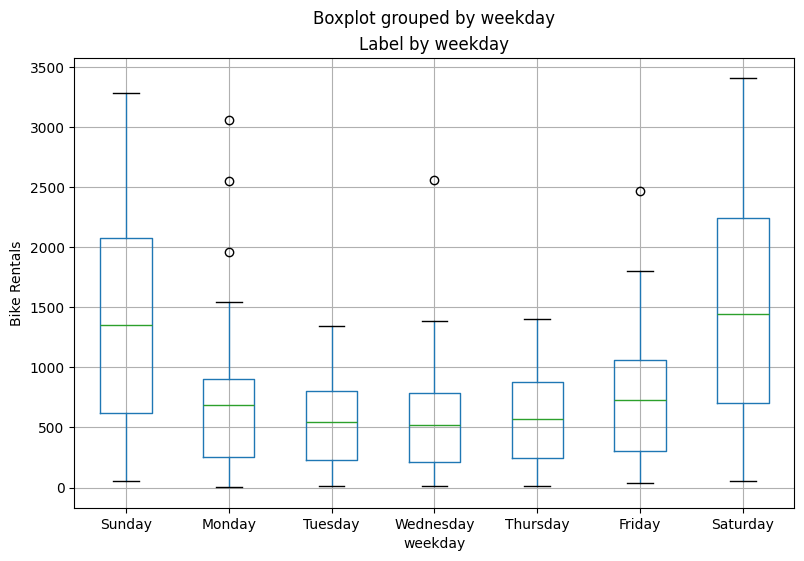

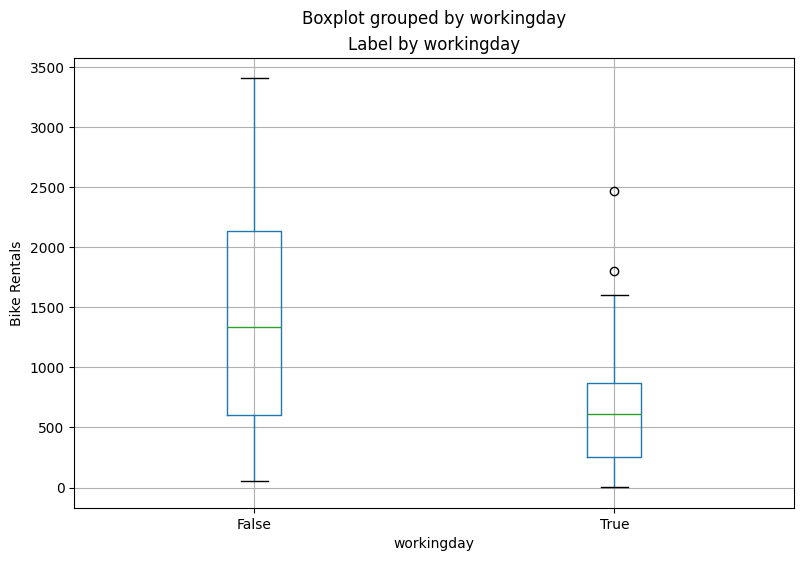

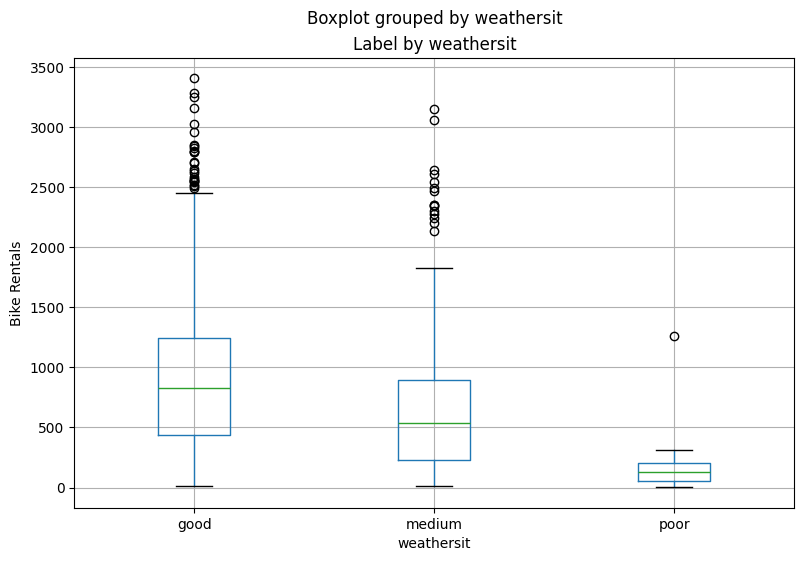

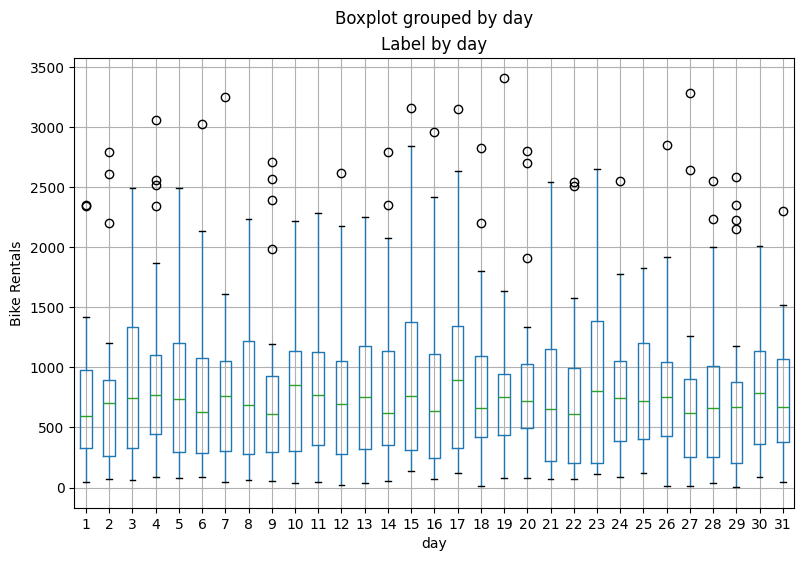

In [19]:
# plot a boxplot for the label by each categorical feature
for col in categorical_features:
    fig = plt.figure(figsize=(9, 6))
    ax = fig.gca()
    df.boxplot(column = 'rentals', by = col, ax = ax)
    ax.set_title('Label by ' + col)
    ax.set_ylabel("Bike Rentals")
plt.show()

The plots show some variance in the relationship between some category values and rentals. For example, there's a clear difference in the distribution of rentals on weekends (**weekday** 0 or 6) and those during the working week (**weekday** 1 to 5). Similarly, there are notable differences for **holiday** and **workingday** categories. There's a noticeable trend that shows different rental distributions in summer and fall months compared to spring and winter months. The **weathersit** category also seems to make a difference in rental distribution. The **day** feature we created for the day of the month shows little variation, indicating that it's probably not predictive of the number of rentals.

## 5. Data cleaning and feature engg.

In [20]:
df.isnull().sum() # no missing values

day           0
mnth          0
year          0
season        0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
rentals       0
date          0
dtype: int64

## 6. Data split

Now that we've explored the data, it's time to use it to train a regression model that uses the features we've identified as potentially predictive to predict the **rentals** label.  The first thing we need to do is to separate the features we want to use to train the model from the label we want it to predict.

In [21]:
# Separate features and labels. We do are going to use only following columns
columns = ['holiday','weekday','workingday','weathersit','temp', 'atemp', 'hum', 'windspeed']

X = df[columns]
y = df['rentals']

print('Features:',X[:10], '\nLabels:', y[:10], sep='\n')

Features:
   holiday    weekday  workingday weathersit      temp     atemp       hum  \
0    False   Saturday       False     medium  0.344167  0.363625  0.805833   
1    False     Sunday       False     medium  0.363478  0.353739  0.696087   
2    False     Monday        True       good  0.196364  0.189405  0.437273   
3    False    Tuesday        True       good  0.200000  0.212122  0.590435   
4    False  Wednesday        True       good  0.226957  0.229270  0.436957   
5    False   Thursday        True       good  0.204348  0.233209  0.518261   
6    False     Friday        True     medium  0.196522  0.208839  0.498696   
7    False   Saturday       False     medium  0.165000  0.162254  0.535833   
8    False     Sunday       False       good  0.138333  0.116175  0.434167   
9    False     Monday        True       good  0.150833  0.150888  0.482917   

   windspeed  
0   0.160446  
1   0.248539  
2   0.248309  
3   0.160296  
4   0.186900  
5   0.089565  
6   0.168726  
7   0.26680

After separating the dataset, we now have numpy arrays named **X** containing the features, and **y** containing the labels.

We *could* train a model using all of the data; but it's common practice in supervised learning to split the data into two subsets; a (typically larger) set with which to train the model, and a smaller "hold-back" set with which to validate the trained model. This enables us to evaluate how well the model performs when used with the validation dataset by comparing the predicted labels to the known labels. It's important to split the data *randomly* (rather than say, taking the first 70% of the data for training and keeping the rest for validation). This helps ensure that the two subsets of data are statistically comparable (so we validate the model with data that has a similar statistical distribution to the data on which it was trained).

To randomly split the data, we'll use the **train_test_split** function in the **scikit-learn** library. This library is one of the most widely used machine learning packages for Python.

In [22]:
# Convert categorical variables to dummy variables
X_encoded = pd.get_dummies(X, drop_first=True)

from sklearn.model_selection import train_test_split

# Split data 70%-30% into training set and test set
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.30, random_state=0)

print ('Training Set: %d rows\nTest Set: %d rows' % (X_train.shape[0], X_test.shape[0]))

Training Set: 511 rows
Test Set: 220 rows


Now we have the following four datasets:

- **X_train**: The feature values we'll use to train the model
- **y_train**: The corresponding labels we'll use to train the model
- **X_test**: The feature values we'll use to validate the model
- **y_test**: The corresponding labels we'll use to validate the model

In [23]:
print(X_train[:10])

     holiday  workingday      temp     atemp       hum  windspeed  \
524    False        True  0.649167  0.597862  0.467917   0.175383   
12     False        True  0.165000  0.150883  0.470417   0.301000   
161    False       False  0.725000  0.678038  0.654583   0.154850   
556    False        True  0.720833  0.664796  0.667500   0.151737   
502    False        True  0.593333  0.572613  0.520000   0.229475   
473    False        True  0.463333  0.457038  0.569167   0.167912   
722    False       False  0.245833  0.259471  0.515417   0.133083   
501    False        True  0.636667  0.595975  0.697917   0.122512   
159    False        True  0.808333  0.757579  0.568333   0.149883   
363    False        True  0.311667  0.318812  0.636667   0.134337   

     weekday_Monday  weekday_Tuesday  weekday_Wednesday  weekday_Thursday  \
524           False            False              False             False   
12            False            False              False              True   
161      

## 7. Train a Regression Model
Now we're ready to train a model by fitting a suitable regression algorithm to the training data. We'll use a *linear regression* algorithm, a common starting point for regression that works by trying to find a linear relationship between the *X* values and the *y* label. The resulting model is a function that conceptually defines a line where every possible X and y value combination intersect.

In Scikit-Learn, training algorithms are encapsulated in *estimators*, and in this case we'll use the **LinearRegression** estimator to train a linear regression model.

In [24]:
# Train the model
from sklearn.linear_model import LinearRegression

# Fit a linear regression model on the training set
model = LinearRegression().fit(X_train, y_train)
print (model)

LinearRegression()


In [25]:
# Get intercept(b0) and coefficients b1, b2, etc
# y = a0 + a1*x1  + a2*x2 + a3*x3 + ...
intercept = model.intercept_
coefficients = model.coef_

# Print results
print(f"Intercept: {intercept:.2f}")

for feature, coef in zip(columns, coefficients):
    print(f"Coefficient for {feature}: {coef:.2f}")
# print("###################")
# for i, coef in enumerate(coefficients):
#     print(f"Coefficient for feature {i}: {coef:.2f}")

Intercept: 965.23
Coefficient for holiday: -3916442667127786.00
Coefficient for weekday: -3916442667128278.50
Coefficient for workingday: 1788.83
Coefficient for weathersit: 304.02
Coefficient for temp: -514.86
Coefficient for atemp: -1158.54
Coefficient for hum: 3916442667127445.00
Coefficient for windspeed: 3916442667127376.50


### 8. Model Performance Evaluation

Now that we've trained the model, we can use it to predict rental counts for the features we held back in our validation dataset. Then we can compare these predictions to the actual label values to evaluate how well (or not!) the model is working.

In [26]:
import numpy as np

predictions = model.predict(X_test)
np.set_printoptions(suppress=True)
y_pred = predictions
print('Predicted labels: ', np.round(predictions)[:10])
print('Actual labels   : ' ,y_test[:10])

Predicted labels:  [1856. 1125. 1004.  -35.  306.  201.  401.  589. 1439.  112.]
Actual labels   :  196    2418
187     754
14      222
31       47
390     244
319     145
299     240
702     555
462    3252
27       38
Name: rentals, dtype: int64


Comparing each prediction with its corresponding "ground truth" actual value isn't a very efficient way to determine how well the model is predicting. Let's see if we can get a better indication by visualizing a scatter plot that compares the predictions to the actual labels. We'll also overlay a trend line to get a general sense for how well the predicted labels align with the true labels.

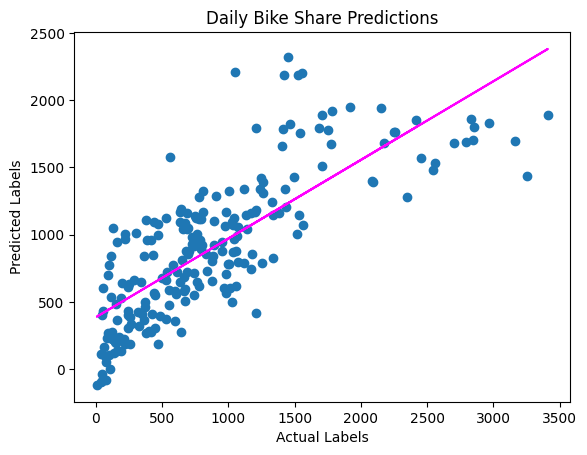

In [27]:
import matplotlib.pyplot as plt

%matplotlib inline

plt.scatter(y_test, predictions)
plt.xlabel('Actual Labels')
plt.ylabel('Predicted Labels')
plt.title('Daily Bike Share Predictions')
# overlay the regression line
z = np.polyfit(y_test, predictions, 1)
p = np.poly1d(z)
plt.plot(y_test,p(y_test), color='magenta')
plt.show()

There's a definite diagonal trend, and the intersections of the predicted and actual values are generally following the path of the trend line; but there's a fair amount of difference between the ideal function represented by the line and the results. This variance represents the *residuals* of the model - in other words, the difference between the label predicted when the model applies the coefficients it learned during training to the validation data, and the actual value of the validation label. These residuals when evaluated from the validation data indicate the expected level of *error* when the model is used with new data for which the label is unknown.

You can quantify the residuals by calculating a number of commonly used evaluation metrics. We'll focus on the following three:

- **Mean Square Error (MSE)**: The mean of the squared differences between predicted and actual values. This yields a relative metric in which the smaller the value, the better the fit of the model
- **Root Mean Square Error (RMSE)**: The square root of the MSE. This yields an absolute metric in the same unit as the label (in this case, numbers of rentals). The smaller the value, the better the model (in a simplistic sense, it represents the average number of rentals by which the predictions are wrong!)
- **Coefficient of Determination (usually known as *R-squared* or R<sup>2</sup>)**: A relative metric in which the higher the value, the better the fit of the model. In essence, this metric represents how much of the variance between predicted and actual label values the model is able to explain.

Let's use Scikit-Learn to calculate these metrics for our model, based on the predictions it generated for the validation data.

In [28]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, predictions)
print("MSE:", mse)

rmse = np.sqrt(mse)
print("RMSE:", rmse)

r2 = r2_score(y_test, predictions)
print("R2:", r2)

MSE: 198702.9590810114
RMSE: 445.7611009060923
R2: 0.6104553200431985


# explanation
- An 𝑅^2 value of 0.62 means that 62% of the variance in the target variable is explained by the mode. In most real-world applications, an 𝑅^2  between 0.5 and 0.8 is considered acceptable.

We've now seen a number of common techniques used to train predictive models for regression. In a real project, you'd likely try a few more algorithms, hyperparameters, and preprocessing transformations; but by now you should have got the general idea. Let's explore how you can use the trained model with new data.

### Use the Trained Model

First, let's save the model.

In [29]:
# save the model
import joblib

# Save the model as a pickle file
filename = 'bike-share.pkl'
joblib.dump(model, filename)

['bike-share.pkl']

Now, we can load it whenever we need it, and use it to predict labels for new data. This is often called *scoring* or *inferencing*.

In [30]:
# Load the model from the file
loaded_model = joblib.load(filename)

# Create a numpy array containing a new observation (for example tomorrow's seasonal and weather forecast information)
X_new = np.array([[False, True, 0.64, 0.59, 0.46, 0.17, False, False , False, False, True, False, False, False]])
print ('New sample: {}'.format(list(X_new[0])))

# Use the model to predict tomorrow's rentals
result = loaded_model.predict(X_new)
print('Prediction: {:.0f} rentals'.format(np.round(result[0])))

New sample: [0.0, 1.0, 0.64, 0.59, 0.46, 0.17, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0]
Prediction: 1146 rentals


C:\Users\hi\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


The model's **predict** method accepts an array of observations, so you can use it to generate multiple predictions as a batch. For example, suppose you have a weather forecast for the next five days; you could use the model to predict bike rentals for each day based on the expected weather conditions.

In [31]:
# An array of features based on five-day weather forecast
X_new = np.array([[False, True, 0.64, 0.59, 0.46, 0.17, False, False , False, False, True, False, False, False],
                 [False, True, 0.64, 0.59, 0.46, 0.17, False, False , False, False, True, False, False, True],
                 [False, True, 0.64, 0.59, 0.46, 0.17, False, False , False, False, True, False, False, False]]
)

# Use the model to predict rentals
results = loaded_model.predict(X_new)
print('5-day rental predictions:')
for prediction in results:
    print(np.round(prediction))

5-day rental predictions:
1146.0
944.0
1146.0


C:\Users\hi\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
